# Viscosity Interpolation

Some tests, examples of viscosity interpolation

As a rule, visoscity varies exponentially with temperature, so that's how we onterpolatie it

But something seemed wrong with some dat from LSFOs

Here's a check, using the KinematicViscosity Object from adios_db.computation

## Conclusion so far:

The fit to an exponential works well for crude oils -- which is what we determined way back when.

However -- it works really poorly for at least some ULSFOs -- maybe other distilled products as well.

## Solution?

First step is to check the residuals, and at least issue a warning.

Next step is to come up with a better interolatio method -- we could do piecwise (linear or exponential), but thatmight extrapolate really badly. That may not be SO bad for environmental conditions -- not a huge temp range --  but not great for labeling and the like.

I tried using only the outside two pooints -- not good.

Could a 3 parameter exponential fit work? IN theory, it should't -- viscosity should tend to zero at infinite temperature, but maybe it wold work OK locally -- at least it would exactly fit three points :-)

Hmm -- piecewise exponential, with the extrapolation using a the fit to the end points?




In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot  as plt
import adios_db.scripting as ads
import adios_db.computation.physical_properties as pp
import csv

In [2]:
# Here's an LSFO with dynamic viscosity data:
EXAMPLE_DATA_DIR = Path(r"C:\Users\rintaro.moriyasu\Oil Databases\noaa-oil-data\data\oil")

with open("viscosity_data.csv") as infile:
    reader = csv.reader(infile)
    next(reader)
    oil_ids = [row[2].strip() for row in reader]

json_files = [EXAMPLE_DATA_DIR/id[:2]/(id+".json") for id in oil_ids]
print(json_files)

[WindowsPath('C:/Users/rintaro.moriyasu/Oil Databases/noaa-oil-data/data/oil/AD/AD00615.json'), WindowsPath('C:/Users/rintaro.moriyasu/Oil Databases/noaa-oil-data/data/oil/AD/AD00638.json'), WindowsPath('C:/Users/rintaro.moriyasu/Oil Databases/noaa-oil-data/data/oil/AD/AD00801.json'), WindowsPath('C:/Users/rintaro.moriyasu/Oil Databases/noaa-oil-data/data/oil/AD/AD00802.json'), WindowsPath('C:/Users/rintaro.moriyasu/Oil Databases/noaa-oil-data/data/oil/AD/AD00809.json'), WindowsPath('C:/Users/rintaro.moriyasu/Oil Databases/noaa-oil-data/data/oil/AD/AD00810.json'), WindowsPath('C:/Users/rintaro.moriyasu/Oil Databases/noaa-oil-data/data/oil/AD/AD00811.json'), WindowsPath('C:/Users/rintaro.moriyasu/Oil Databases/noaa-oil-data/data/oil/AD/AD00813.json'), WindowsPath('C:/Users/rintaro.moriyasu/Oil Databases/noaa-oil-data/data/oil/AD/AD01180.json'), WindowsPath('C:/Users/rintaro.moriyasu/Oil Databases/noaa-oil-data/data/oil/AD/AD01235.json'), WindowsPath('C:/Users/rintaro.moriyasu/Oil Databa

In [3]:
oils = [ads.Oil.from_file(filename) for filename in json_files]

NO00123 ['E062: Viscosity data is not strictly decreasing', 'W009: Distillation fraction recovered is missing or invalid']
NO00124 ['W009: Distillation fraction recovered is missing or invalid']


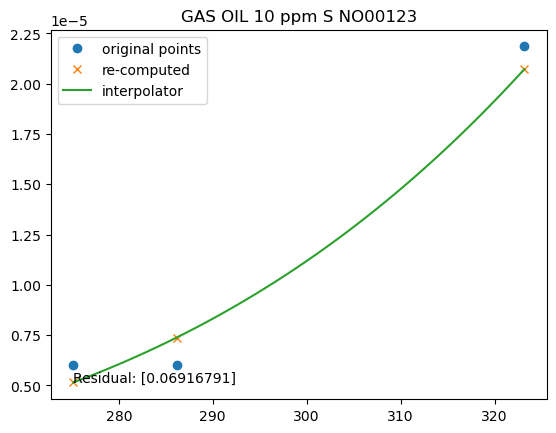

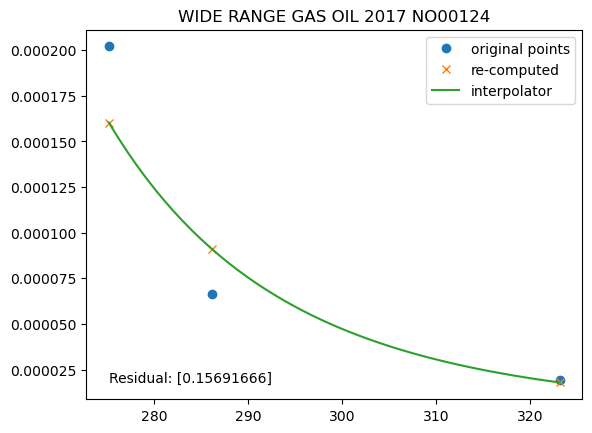

In [21]:
for oil in oils[245:]:
    print(oil.oil_id, oil.validate())
    oil_name = oil.metadata.name
    #print(oil_name)
    KV = pp.KinematicViscosity(oil)

    visc = KV.kviscs
    temps = KV.temps
    visc2 = KV.at_temp(temps)

    temps3 = np.linspace(min(temps), max(temps))
    visc3 = KV.at_temp(temps3)
    fig, ax = plt.subplots()
    ax.set_title(oil_name +" " + oil.oil_id)
    ax.plot(temps, visc, 'o')
    ax.plot(temps, visc2, 'x')
    ax.plot(temps3, visc3)
    ax.legend(["original points", "re-computed", "interpolator"])
    ax.text(min(temps3),min(visc3) , f"Residual: {KV.residuals}")


## What if we only ue the outer points?

In [5]:
datafile = EXAMPLE_DATA_DIR / 'record_with_only_dynamic_viscosity.json'
oil = ads.Oil.from_file(datafile)

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\rintaro.moriyasu\\Oil Databases\\noaa-oil-data\\data\\oil\\record_with_only_dynamic_viscosity.json'

In [ ]:

oil_name = oil.metadata.name
print(oil_name)
KV = pp.KinematicViscosity(oil)

# get the original points
visc = KV.kviscs
temps = KV.temps

# keep only the end two values
KV.kviscs = (KV.kviscs[0], KV.kviscs[-1])
KV.temps = (KV.temps[0], KV.temps[-1])
# re-initialize
KV.initialize()

visc2 = KV.at_temp(temps)

temps3 = np.linspace(min(temps), max(temps))
visc3 = KV.at_temp(temps3)
fig, ax = plt.subplots()
ax.set_title(oil_name)
ax.plot(temps, visc, 'o')
ax.plot(temps, visc2, 'x')
ax.plot(temps3, visc3)
ax.legend(["original points", "re-computed", "interpolator"])
ax.text(min(temps3),min(visc3) , f"Residual: {KV.residuals}")

